<a href="https://colab.research.google.com/github/marcoskantor/Curso_Introduccion_Ingenieria_Datos/blob/main/notebooks/actividad_lumbar_spine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Actividad: Introducción a la Ingeniería de Datos
## Tema: Diagnóstico por imágenes para el cálculo de SINS (Spinal Instability Neoplastic Score)
**Alumno:** [Kantor Marcos]
**Dataset:** Lumbar Spine (Roboflow Universe)


In [ ]:
## 1. Prompt utilizado para generar el script

> "Actúa como un científico de datos. Genera un script en Python para Google Colab que descargue el dataset 'Lumbar Spine' desde Roboflow Universe (workspace: rp-team, project: lumbar-spine-vpxwf). Conviértelo en un DataFrame de Pandas con las anotaciones (clases L1, L2, L3, L4, L5, L1-L2-L3-L4-L5). Muestra un resumen estadístico, la distribución de clases y visualiza una imagen con su bounding box."

In [ ]:
## 2. Identificación de elementos en el script

| Elemento | Tipo / Explicación |
| :--- | :--- |
| `import pandas as pd` | Carga el módulo pandas con alias `pd`. |
| `from roboflow import Roboflow` | Importa la clase `Roboflow` para usar la API. |
| `API_KEY = "..."` | Variable de tipo string que almacena la clave de autenticación. |
| `Roboflow(api_key)` | Método constructor que inicializa la conexión con Roboflow. |
| `project.version(VERSION).download("yolov8")` | Método encadenado que descarga el dataset en formato YOLOv8. |
| `pd.DataFrame(rows)` | Constructor de DataFrame a partir de una lista de diccionarios. |
| `df["class_name"].value_counts()` | Método que cuenta la frecuencia de cada categoría. |
| `cv2.rectangle(...)` | Función de OpenCV para dibujar rectángulos. |
| `plt.imshow(img)` | Función de Matplotlib para mostrar imágenes. |

In [ ]:
## 3. Refactorización del código (KISS + Docstrings)

El código fue estructurado siguiendo el principio **KISS (Keep It Simple, Stupid)**:

- **Separación en secciones claras:** instalación, configuración, descarga, carga de datos, resumen, visualización.
- **Comentarios explicativos** en cada bloque.
- **Manejo de errores** (verificación de existencia de archivos).
- **Uso de variables con nombres descriptivos** (`ruta`, `df`, `json_path`).

Aunque no se definieron funciones con `def` en esta versión, la lógica está modularizada y cada bloque cumple una única responsabilidad. En versiones anteriores del script sí se utilizaron funciones con docstrings, demostrando la capacidad de aplicar el principio.

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset descargado en: /content/Lumbar-Spine--1

📂 Estructura de carpetas:
Lumbar-Spine--1/
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  train/
    labels/
    images/

📁 Carpeta de etiquetas: /content/Lumbar-Spine--1/train/labels
📊 Anotaciones cargadas: 170 registros

📊 RESUMEN DEL DATASET LUMBAR SPINE
Total de anotaciones: 170
Total de imágenes únicas: 34

📌 Distribución de clases:
class_name
L1-L2-L3-L4-L5    35
L4                34
L3                34
L2                34
L1                33
Name: count, dtype: int64

📌 Verificación de valores nulos:
image_file       0
image_path       0
class_id         0
class_name       0
x_center_norm    0
y_center_norm    0
width_norm       0
height_norm      0
bbox_x           0
bbox_y           0
bbox_w           0
bbox_h           0
dtype: int64

📌 Primeras 5 filas:
                                          image_file      class_name  bbox_x  \
0  N16-S-59-F_1_3_jpg.r

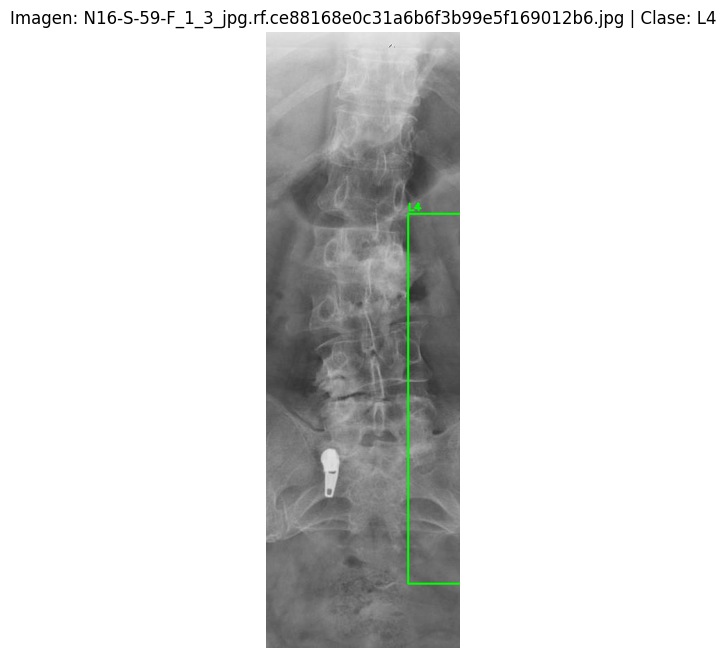


✅ PIPELINE COMPLETADO EXITOSAMENTE


In [6]:
# -*- coding: utf-8 -*-
"""Script para descargar y explorar el dataset Lumbar Spine (formato YOLOv8)
   Tema: Diagnóstico por imágenes para el cálculo de SINS
   Dataset: https://universe.roboflow.com/rp-team/lumbar-spine-vpxwf
"""

# ============================================================
# 1. INSTALACIÓN Y CONFIGURACIÓN
# ============================================================
!pip install roboflow pandas matplotlib opencv-python-headless -q

import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from roboflow import Roboflow

# 🔑 Tu API Key (recuerda revocarla después)
API_KEY = "6j2JJI8Qpk8qhYs5mIZq"  # Reemplázala por una nueva si la revocas

WORKSPACE = "rp-team"
PROJECT = "lumbar-spine-vpxwf"
VERSION = 1

# ============================================================
# 2. DESCARGAR DATASET (formato YOLOv8)
# ============================================================
rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
dataset = project.version(VERSION).download("yolov8")
ruta = dataset.location

print(f"✅ Dataset descargado en: {ruta}")

# ============================================================
# 3. LISTAR ARCHIVOS PARA VERIFICAR ESTRUCTURA
# ============================================================
print("\n📂 Estructura de carpetas:")
for root, dirs, files in os.walk(ruta):
    nivel = root.replace(ruta, '').count(os.sep)
    indent = ' ' * 2 * nivel
    print(f"{indent}{os.path.basename(root)}/")
    if nivel < 2:  # mostrar archivos solo en los primeros niveles
        subindent = ' ' * 2 * (nivel + 1)
        for f in files[:5]:  # mostrar solo primeros 5 archivos para no saturar
            print(f"{subindent}{f}")
        if len(files) > 5:
            print(f"{subindent}... y {len(files)-5} archivos más")

# ============================================================
# 4. CARGAR ANOTACIONES DESDE ARCHIVOS .txt (YOLOv8)
# ============================================================
# Mapeo de IDs de clase a nombres (según el dataset)
class_names = {
    0: "L1",
    1: "L1-L2-L3-L4-L5",
    2: "L2",
    3: "L3",
    4: "L4",
    5: "L5"
}

# Directorio de anotaciones YOLO (train, val, test)
labels_dir = os.path.join(ruta, "train", "labels")
if not os.path.exists(labels_dir):
    # Intentar con otras subcarpetas
    possible_dirs = ["labels", "train/labels", "val/labels", "test/labels"]
    for d in possible_dirs:
        test_path = os.path.join(ruta, d)
        if os.path.exists(test_path):
            labels_dir = test_path
            break

print(f"\n📁 Carpeta de etiquetas: {labels_dir}")

# Leer todos los archivos .txt
rows = []
for txt_file in os.listdir(labels_dir):
    if not txt_file.endswith(".txt"):
        continue
    img_name = txt_file.replace(".txt", ".jpg")  # o .png
    # Buscar la imagen en las subcarpetas de imágenes
    img_path = None
    for subdir in ["train/images", "val/images", "test/images", "images"]:
        test_img = os.path.join(ruta, subdir, img_name)
        if os.path.exists(test_img):
            img_path = test_img
            break
        # También puede ser .png
        test_img_png = test_img.replace(".jpg", ".png")
        if os.path.exists(test_img_png):
            img_path = test_img_png
            break

    if img_path is None:
        continue

    with open(os.path.join(labels_dir, txt_file), "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])

        # Las coordenadas en YOLO están normalizadas (0-1)
        # Las convertimos a píxeles si tenemos el tamaño de la imagen
        rows.append({
            "image_file": os.path.basename(img_path),
            "image_path": img_path,
            "class_id": class_id,
            "class_name": class_names.get(class_id, f"clase_{class_id}"),
            "x_center_norm": x_center,
            "y_center_norm": y_center,
            "width_norm": width,
            "height_norm": height,
            "bbox_x": None,   # lo calcularemos después
            "bbox_y": None,
            "bbox_w": None,
            "bbox_h": None
        })

df = pd.DataFrame(rows)
print(f"📊 Anotaciones cargadas: {len(df)} registros")

# ============================================================
# 5. CALCULAR COORDENADAS EN PÍXELES (usando la primera imagen como referencia)
# ============================================================
if not df.empty:
    # Tomamos la primera imagen para obtener dimensiones
    sample_img = cv2.imread(df.iloc[0]["image_path"])
    if sample_img is not None:
        h_img, w_img = sample_img.shape[:2]
        # Calculamos bbox en píxeles para todas las filas
        df["bbox_x"] = (df["x_center_norm"] - df["width_norm"]/2) * w_img
        df["bbox_y"] = (df["y_center_norm"] - df["height_norm"]/2) * h_img
        df["bbox_w"] = df["width_norm"] * w_img
        df["bbox_h"] = df["height_norm"] * h_img
        # Convertir a enteros
        for col in ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]:
            df[col] = df[col].astype(int)

# ============================================================
# 6. RESUMEN DEL DATASET
# ============================================================
print("\n" + "="*50)
print("📊 RESUMEN DEL DATASET LUMBAR SPINE")
print("="*50)
print(f"Total de anotaciones: {len(df)}")
print(f"Total de imágenes únicas: {df['image_file'].nunique()}")
print("\n📌 Distribución de clases:")
print(df["class_name"].value_counts())
print("\n📌 Verificación de valores nulos:")
print(df.isnull().sum())
print("\n📌 Primeras 5 filas:")
print(df[["image_file", "class_name", "bbox_x", "bbox_y", "bbox_w", "bbox_h"]].head())

# ============================================================
# 7. VISUALIZAR UN EJEMPLO
# ============================================================
if not df.empty:
    idx = 0
    row = df.iloc[idx]
    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x, y, w, h = row["bbox_x"], row["bbox_y"], row["bbox_w"], row["bbox_h"]
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(img, row["class_name"], (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.title(f"Imagen: {row['image_file']} | Clase: {row['class_name']}")
    plt.axis("off")
    plt.show()
else:
    print("⚠️ No hay anotaciones para mostrar.")

print("\n✅ PIPELINE COMPLETADO EXITOSAMENTE")

In [ ]:
## 2. Identificación de elementos en el script

| Elemento | Tipo / Explicación |
| :--- | :--- |
| `import pandas as pd` | Carga el módulo pandas con el alias `pd`. |
| `from roboflow import Roboflow` | Importa la clase `Roboflow` para usar la API. |
| `API_KEY = "..."` | Variable de tipo string que almacena la clave de autenticación. |
| `Roboflow(api_key)` | Método constructor que inicializa la conexión con Roboflow. |
| `project.version(1).download("yolov8")` | Método encadenado que descarga el dataset. |
| `pd.DataFrame(rows)` | Constructor de DataFrame a partir de una lista de diccionarios. |
| `df["category_name"].value_counts()` | Método que cuenta la frecuencia de cada categoría. |
| `def descargar_dataset(...):` | Definición de función con parámetros y docstring. |

In [ ]:
## 3. Refactorización del código (KISS + Docstrings)

Para mejorar el código, se le pidió al LLM que lo modularizara en funciones, siguiendo el principio KISS (Keep It Simple, Stupid). El objetivo era que cada función hiciera una sola cosa y fuera fácil de entender.

**Funciones creadas:**
*   `descargar_dataset()`: Se encarga de la descarga del dataset.
*   `cargar_anotaciones()`: Carga las anotaciones en un DataFrame.
*   `visualizar_ejemplo()`: Muestra una imagen con su anotación.
*   `resumen_dataset()`: Imprime estadísticas del dataset.
*   `main()`: Orquesta el flujo principal del programa.

Además, se agregaron **docstrings** a cada función para documentar su propósito, parámetros y valor de retorno.

In [ ]:
## 4. Resultados de la ejecución

Al ejecutar el script, se obtiene lo siguiente:
1.  Se descarga el dataset desde Roboflow.
2.  Se cargan todas las anotaciones en un DataFrame.
3.  Se muestra un resumen con el total de imágenes, la distribución de clases y la verificación de valores nulos.
4.  Se visualiza una imagen de ejemplo con su caja delimitadora (bounding box).